# Exploring LFPs before ripple detection

This notebook covers only the first three planning steps for Question 1:

1. Define what we eventually mean by **ripple density**.
2. Inspect the LFPs, spectra, and variation across channels in one mouse.
3. Fix and document a preliminary **100–200 Hz** ripple band.

**Deliberate stopping point:** this notebook does not detect or count ripple events.

## Step 1 — Operational definition

For the eventual analysis, ripple density will mean:

$$\text{ripple density} = \frac{\text{number of accepted ripple events}}{\text{valid recording duration in minutes}}$$

- Units: **events/minute**.
- Events will eventually be detected per LFP channel, then summarized within each brain area and mouse.
- The mouse/session—not a channel or an event—will be the independent observation for group inference.
- Mouse 12 will be excluded from the group analysis because it duplicates mouse 11.
- The precise detector, channel aggregation, thresholds, duration limits, and artifact rejection remain intentionally undecided.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import trapezoid
from scipy.signal import butter, sosfiltfilt, sosfreqz, welch

FS = 500.0
MOUSE_ID = 1
EXCLUDED_MICE = {12}
RIPPLE_BAND = (100.0, 200.0)
COLORS = {1: "#0072B2", 2: "#E69F00", 3: "#009E73"}

# Work whether the notebook is launched from the repository root or code-snippets/.
DATA_DIR = next(path for path in (Path("data"), Path("../data")) if path.exists())
assert MOUSE_ID not in EXCLUDED_MICE
print(f"Data directory: {DATA_DIR.resolve()}")

Data directory: C:\Users\nils\Documents\Programació\Brainhack\data


## Step 2 — Inspect mouse 1

Mouse 1 is used only as an initial visual and computational check. No conclusion about which area has the highest ripple density will be drawn from this mouse alone.

In [2]:
mouse_dir = DATA_DIR / str(MOUSE_ID)
lfps = {area: np.load(mouse_dir / f"lfp_{area}.npy", mmap_mode="r") for area in (1, 2, 3)}

lfp_summary = pd.DataFrame(
    [
        {
            "brain_area": area,
            "n_channels": lfp.shape[0],
            "n_samples": lfp.shape[1],
            "duration_min": lfp.shape[1] / FS / 60,
            "dtype": str(lfp.dtype),
        }
        for area, lfp in lfps.items()
    ]
)
lfp_summary

,brain_area,n_channels,n_samples,duration_min,dtype
0,1,28,1675486,55.849533,float64
1,2,25,1675486,55.849533,float64
2,3,47,1675486,55.849533,float64


### Short raw-LFP view

The center channel of each area is shown over the same two-second interval. Separate y-axes are intentional: this is a morphology/artifact check, not an amplitude comparison.

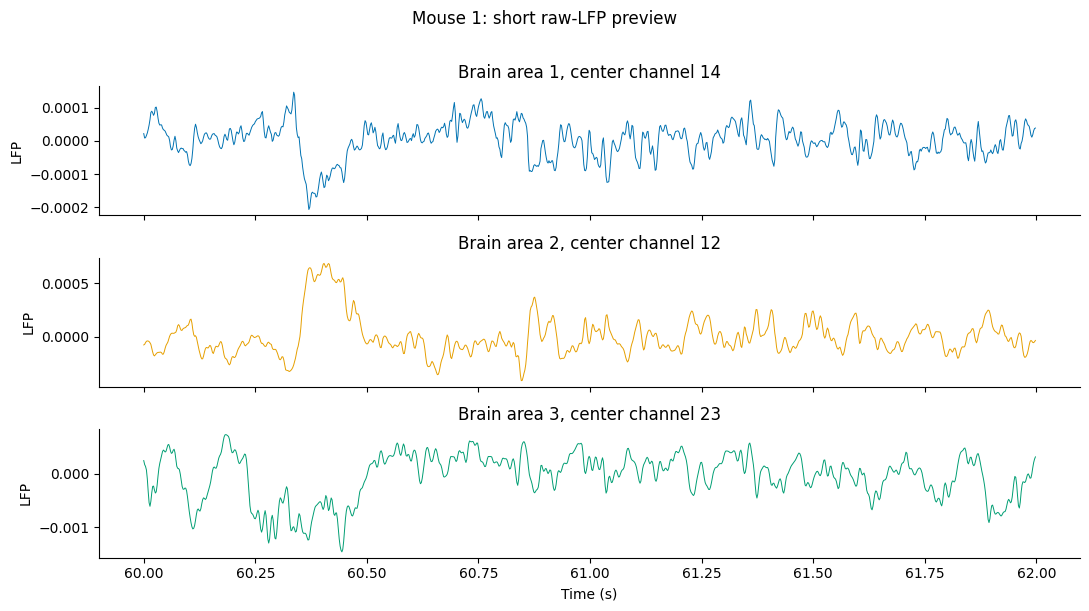

In [3]:
preview_start_s = 60.0
preview_duration_s = 2.0
start = int(preview_start_s * FS)
stop = start + int(preview_duration_s * FS)
time = np.arange(stop - start) / FS + preview_start_s

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for area, ax in zip((1, 2, 3), axes):
    channel = lfps[area].shape[0] // 2
    trace = np.asarray(lfps[area][channel, start:stop])
    ax.plot(time, trace, color=COLORS[area], linewidth=0.7)
    ax.set_ylabel("LFP")
    ax.set_title(f"Brain area {area}, center channel {channel}")
    ax.spines[["top", "right"]].set_visible(False)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Mouse 1: short raw-LFP preview", y=1.01)
fig.tight_layout()
plt.show()

### Channel-wise power spectra

To keep this first inspection quick while sampling the whole recording, Welch spectra are computed from five evenly spaced 120-second windows and averaged. Every channel is included. The solid line is the channel median and the shaded region is the channel interquartile range.

In [4]:
def chunk_averaged_welch(trace, fs=FS, chunk_s=120.0, n_chunks=5):
    chunk_n = min(len(trace), int(chunk_s * fs))
    starts = np.linspace(0, len(trace) - chunk_n, n_chunks).round().astype(int)
    chunk_psds = []
    for chunk_start in starts:
        segment = np.asarray(trace[chunk_start : chunk_start + chunk_n])
        frequencies, psd = welch(
            segment,
            fs=fs,
            nperseg=int(2 * fs),
            noverlap=int(fs),
            detrend="constant",
        )
        chunk_psds.append(psd)
    return frequencies, np.mean(chunk_psds, axis=0)


spectra = {}
for area, lfp in lfps.items():
    channel_psds = []
    for channel in range(lfp.shape[0]):
        frequencies, psd = chunk_averaged_welch(lfp[channel])
        channel_psds.append(psd)
    spectra[area] = np.stack(channel_psds)
    print(f"Area {area}: spectra for {spectra[area].shape[0]} channels")

Area 1: spectra for 28 channels


Area 2: spectra for 25 channels


Area 3: spectra for 47 channels


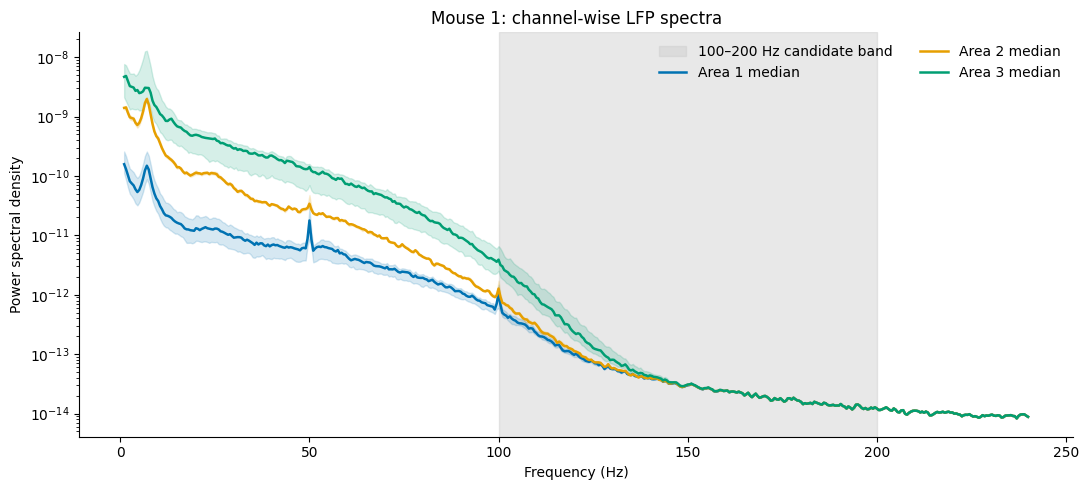

In [5]:
plot_mask = (frequencies >= 1) & (frequencies <= 240)
fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(*RIPPLE_BAND, color="0.8", alpha=0.45, label="100–200 Hz candidate band")
for area in (1, 2, 3):
    median = np.median(spectra[area], axis=0)
    q25, q75 = np.percentile(spectra[area], [25, 75], axis=0)
    ax.semilogy(
        frequencies[plot_mask], median[plot_mask], color=COLORS[area], linewidth=1.8, label=f"Area {area} median"
    )
    ax.fill_between(frequencies[plot_mask], q25[plot_mask], q75[plot_mask], color=COLORS[area], alpha=0.16)
ax.set(xlabel="Frequency (Hz)", ylabel="Power spectral density", title="Mouse 1: channel-wise LFP spectra")
ax.legend(frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### High-frequency power variation across channels

Absolute 100–200 Hz power is useful for spotting channel-scale differences. Relative power divides it by 1–240 Hz power, reducing—but not eliminating—differences caused by overall signal scale. These are descriptive spectral summaries, **not ripple-density estimates**.

In [6]:
band_mask = (frequencies >= RIPPLE_BAND[0]) & (frequencies <= RIPPLE_BAND[1])
broadband_mask = (frequencies >= 1) & (frequencies <= 240)
power_rows = []
for area in (1, 2, 3):
    for channel, psd in enumerate(spectra[area]):
        band_power = trapezoid(psd[band_mask], frequencies[band_mask])
        broadband_power = trapezoid(psd[broadband_mask], frequencies[broadband_mask])
        power_rows.append(
            {
                "brain_area": area,
                "channel": channel,
                "band_power": band_power,
                "relative_band_power": band_power / broadband_power,
            }
        )
channel_power = pd.DataFrame(power_rows)

channel_power.groupby("brain_area").agg(
    n_channels=("channel", "count"),
    median_band_power=("band_power", "median"),
    median_relative_power=("relative_band_power", "median"),
    min_relative_power=("relative_band_power", "min"),
    max_relative_power=("relative_band_power", "max"),
)

,n_channels,median_band_power,median_relative_power,min_relative_power,max_relative_power
brain_area,,,,,
1,28,7.630130e-12,0.006274,0.002252,0.011947
2,25,9.603143e-12,0.000767,0.000633,0.000872
3,47,2.697405e-11,0.000952,0.000232,0.001849


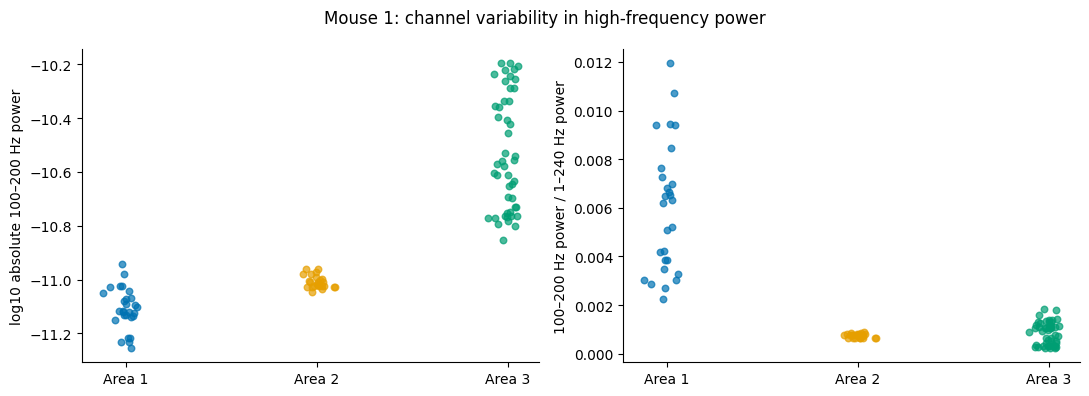

In [7]:
rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for area in (1, 2, 3):
    subset = channel_power[channel_power.brain_area == area]
    jitter = rng.normal(0, 0.045, len(subset))
    axes[0].scatter(area + jitter, np.log10(subset.band_power), color=COLORS[area], alpha=0.7, s=22)
    axes[1].scatter(area + jitter, subset.relative_band_power, color=COLORS[area], alpha=0.7, s=22)
for ax in axes:
    ax.set_xticks([1, 2, 3], ["Area 1", "Area 2", "Area 3"])
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log10 absolute 100–200 Hz power")
axes[1].set_ylabel("100–200 Hz power / 1–240 Hz power")
fig.suptitle("Mouse 1: channel variability in high-frequency power")
fig.tight_layout()
plt.show()

## Step 3 — Preliminary ripple band: 100–200 Hz

The sampling rate is 500 Hz, so Nyquist is 250 Hz. A proposed 150–240 Hz band would place its upper transition very close to Nyquist and would discard possible lower-frequency ripple energy. For the first detector iteration we therefore choose **100–200 Hz**.

This is a pragmatic analysis band, not evidence that every 100–200 Hz burst is a hippocampal sharp-wave ripple. Event morphology, duration, artifacts, and ideally a sharp-wave component still need validation.

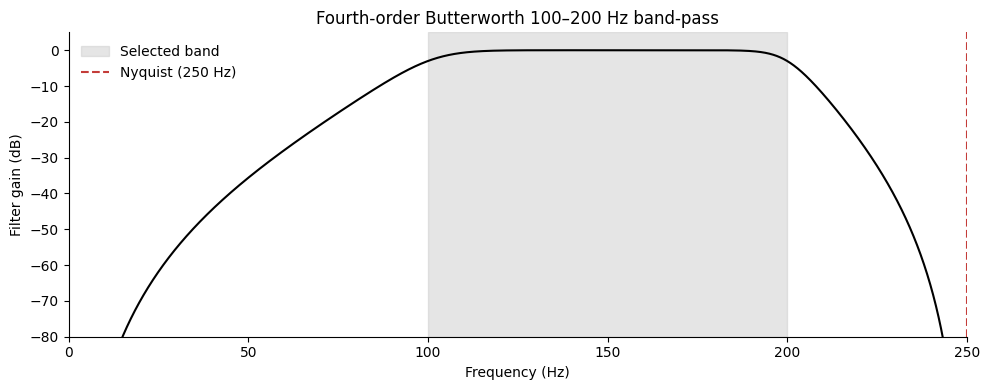

In [8]:
ripple_sos = butter(4, RIPPLE_BAND, btype="bandpass", fs=FS, output="sos")
response_frequency, response = sosfreqz(ripple_sos, worN=4096, fs=FS)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(response_frequency, 20 * np.log10(np.maximum(np.abs(response), 1e-8)), color="black")
ax.axvspan(*RIPPLE_BAND, color="0.8", alpha=0.5, label="Selected band")
ax.axvline(FS / 2, color="#C43C39", linestyle="--", label="Nyquist (250 Hz)")
ax.set(
    xlim=(0, 250),
    ylim=(-80, 5),
    xlabel="Frequency (Hz)",
    ylabel="Filter gain (dB)",
    title="Fourth-order Butterworth 100–200 Hz band-pass",
)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### Filtered preview—not event detection

The same center channels are filtered only to inspect the signal scale and morphology in the selected band. No envelope, threshold, event count, or density is computed.

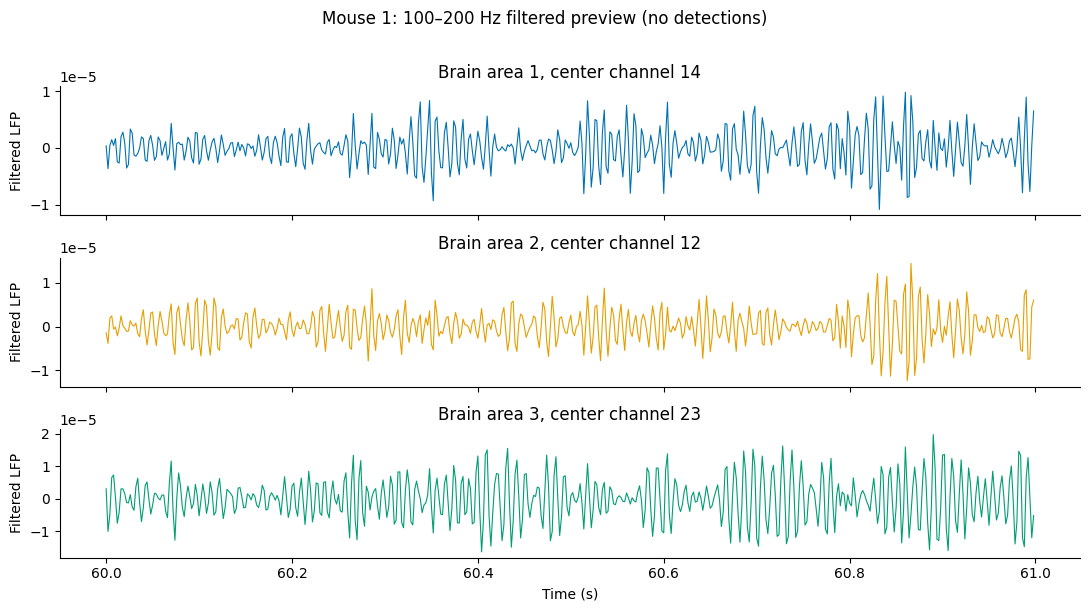

In [9]:
filtered_preview_s = 1.0
filtered_stop = start + int(filtered_preview_s * FS)
filtered_time = np.arange(filtered_stop - start) / FS + preview_start_s

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for area, ax in zip((1, 2, 3), axes):
    channel = lfps[area].shape[0] // 2
    # Add padding before filtering to reduce edge transients in the displayed interval.
    pad = int(2 * FS)
    padded = np.asarray(lfps[area][channel, start - pad : filtered_stop + pad])
    filtered = sosfiltfilt(ripple_sos, padded)[pad:-pad]
    ax.plot(filtered_time, filtered, color=COLORS[area], linewidth=0.8)
    ax.set_ylabel("Filtered LFP")
    ax.set_title(f"Brain area {area}, center channel {channel}")
    ax.spines[["top", "right"]].set_visible(False)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Mouse 1: 100–200 Hz filtered preview (no detections)", y=1.01)
fig.tight_layout()
plt.show()

## Step 4 — Compare a classical detector with label-free ML

RMS and Hilbert envelopes are too closely related to provide a genuinely independent comparison. Instead, Mouse 1 will be analyzed with:

1. **Robust RMS detector:** a transparent time-domain baseline operating on the 100–200 Hz filtered signal.
2. **Unsupervised spectral-novelty detector:** an STFT representation followed by a Gaussian mixture density model. The GMM learns the ordinary spectral distribution directly from Mouse 1; rare deviations in the ripple-like direction are treated as candidates, without imported labels.

For this exploratory comparison, both methods use the same three evenly spaced channels per area. This is not yet the final all-channel or all-mouse analysis.

In [10]:
import os

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

from scipy.ndimage import binary_closing, uniform_filter1d
from scipy.signal import spectrogram
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler

RNG = np.random.default_rng(20260705)
SELECTED_CHANNELS = {
    area: np.unique(np.linspace(0, lfp.shape[0] - 1, 3).round().astype(int))
    for area, lfp in lfps.items()
}
SELECTED_CHANNELS

{1: array([ 0, 14, 27]), 2: array([ 0, 12, 24]), 3: array([ 0, 23, 46])}

### Pipeline A — robust RMS detector

- Zero-phase 100–200 Hz filter.
- 20 ms moving RMS.
- Channel-wise median/MAD normalization.
- Event starts above 4 robust SD and boundaries extend to 2 robust SD.
- Accepted duration: 20–200 ms.
- Candidates overlapping raw amplitudes above 20 robust SD are rejected as likely artifacts.

In [11]:
def robust_z(values):
    values = np.asarray(values)
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= np.finfo(float).eps:
        return np.zeros_like(values, dtype=float)
    return (values - median) / scale


def contiguous_regions(mask):
    changes = np.diff(np.pad(np.asarray(mask, dtype=np.int8), (1, 1)))
    return list(zip(np.flatnonzero(changes == 1), np.flatnonzero(changes == -1)))


def rms_events(trace, fs=FS, start_z=4.0, end_z=2.0,
               min_ms=20.0, max_ms=200.0, artifact_z=20.0):
    x = np.asarray(trace, dtype=float)
    filtered = sosfiltfilt(ripple_sos, x)
    window = max(1, int(round(0.020 * fs)))
    rms = np.sqrt(uniform_filter1d(filtered ** 2, size=window))
    score = robust_z(rms)
    raw_score = np.abs(robust_z(x))
    min_samples = int(np.ceil(min_ms * fs / 1000))
    max_samples = int(np.floor(max_ms * fs / 1000))
    edge = int(fs)
    events = []
    for event_start, event_stop in contiguous_regions(score >= end_z):
        duration_samples = event_stop - event_start
        if event_start < edge or event_stop > len(x) - edge:
            continue
        if not min_samples <= duration_samples <= max_samples:
            continue
        if score[event_start:event_stop].max() < start_z:
            continue
        if raw_score[event_start:event_stop].max() > artifact_z:
            continue
        peak = event_start + np.argmax(score[event_start:event_stop])
        events.append({
            'start_s': event_start / fs,
            'stop_s': event_stop / fs,
            'center_s': peak / fs,
            'duration_ms': duration_samples / fs * 1000,
            'strength': float(score[peak]),
        })
    return pd.DataFrame(events), score.astype(np.float32)


rms_results = {}
rms_rows = []
for area, channels in SELECTED_CHANNELS.items():
    for channel in channels:
        events, score = rms_events(lfps[area][channel])
        key = (area, int(channel))
        rms_results[key] = {'events': events, 'score': score}
        rate = len(events) / (lfps[area].shape[1] / FS / 60)
        rms_rows.append({
            'method': 'Robust RMS', 'brain_area': area, 'channel': channel,
            'n_events': len(events), 'events_per_min': rate,
        })
rms_channel_results = pd.DataFrame(rms_rows)
rms_channel_results

,method,brain_area,channel,n_events,events_per_min
0,Robust RMS,1,0,2029,36.329757
1,Robust RMS,1,14,1445,25.873090
2,Robust RMS,1,27,1446,25.890995
3,Robust RMS,2,0,1756,31.441624
4,Robust RMS,2,12,1508,27.001121
5,Robust RMS,2,24,1562,27.968005
6,Robust RMS,3,0,1412,25.282217
7,Robust RMS,3,23,1632,29.221372
8,Robust RMS,3,46,1595,28.558878


### Pipeline B — frequency-whitened candidate GMM

Each channel is represented by overlapping 64 ms STFT windows evaluated every 10 ms. Log power is whitened separately at every frequency using its temporal median and MAD. Consequently, a large baseline at 100 Hz cannot dominate simply because it has more absolute power than 180 Hz.

Permissive candidates are contiguous windows whose mean of the three strongest whitened 100–200 Hz bins exceeds 1.5 robust SD. This gate is intentionally sensitive; the GMM, rather than the gate, is responsible for separating candidate morphology. Each candidate is represented by:

- whitened excess power in four 25 Hz sub-bands;
- relative ripple-band power, spectral entropy, and broadband excess;
- number of elevated ripple-frequency bins.

Duration is retained as metadata and as a 20–300 ms inclusion rule, but is not given to the GMM. A three-component GMM is fitted only to these candidates—not to ordinary recording windows. The putative ripple component is selected as the component with high excess across the ripple sub-bands, high relative ripple power, many elevated frequency bins, and low spectral entropy. This remains label-free and still requires visual/physiological validation.

In [12]:
SUBBANDS = ((100, 125), (125, 150), (150, 175), (175, 201))
GMM_FEATURES = [
    'excess_100_125', 'excess_125_150',
    'excess_150_175', 'excess_175_200',
    'relative_power_z', 'entropy_z', 'broadband_excess_z',
    'n_elevated_bins',
]


def whiten_log_power(psd):
    log_power = np.log10(psd + np.finfo(float).tiny)
    median = np.median(log_power, axis=1, keepdims=True)
    mad = np.median(np.abs(log_power - median), axis=1, keepdims=True)
    scale = 1.4826 * mad
    scale[scale <= np.finfo(float).eps] = 1.0
    return (log_power - median) / scale


def stft_candidates(trace, area, channel, fs=FS, candidate_z=1.5):
    frequencies, times, psd = spectrogram(
        np.asarray(trace, dtype=float),
        fs=fs,
        window='hann',
        nperseg=32,
        noverlap=27,
        nfft=32,
        detrend='constant',
        scaling='density',
        mode='psd',
    )
    whitened = whiten_log_power(psd)
    ripple = (frequencies >= 100) & (frequencies <= 200)
    broadband = (frequencies >= 20) & (frequencies <= 240)
    ripple_whitened = whitened[ripple]
    # Requiring several elevated bins is less vulnerable to one noisy FFT bin.
    top_three = np.partition(ripple_whitened, -3, axis=0)[-3:]
    candidate_score = np.mean(top_three, axis=0)

    eps = np.finfo(float).tiny
    ripple_power = np.mean(psd[ripple], axis=0)
    broadband_power = np.mean(psd[broadband], axis=0)
    relative_power = np.log10((ripple_power + eps) / (broadband_power + eps))
    relative_power_z = robust_z(relative_power)
    broadband_excess_z = robust_z(np.log10(broadband_power + eps))
    normalized_spectrum = psd[broadband] / (
        np.sum(psd[broadband], axis=0, keepdims=True) + eps
    )
    entropy = -np.sum(
        normalized_spectrum * np.log(normalized_spectrum + eps), axis=0
    ) / np.log(normalized_spectrum.shape[0])
    entropy_z = robust_z(entropy)

    hop_s = float(np.median(np.diff(times)))
    mask = binary_closing(candidate_score >= candidate_z, structure=np.ones(2))
    candidates = []
    for start_index, stop_index in contiguous_regions(mask):
        duration_s = (stop_index - start_index) * hop_s
        if not 0.020 <= duration_s <= 0.300:
            continue
        peak_index = start_index + np.argmax(candidate_score[start_index:stop_index])
        row = {
            'brain_area': area,
            'channel': int(channel),
            'start_s': float(times[start_index] - hop_s / 2),
            'stop_s': float(times[stop_index - 1] + hop_s / 2),
            'center_s': float(times[peak_index]),
            'duration_ms': duration_s * 1000,
            'candidate_score': float(candidate_score[peak_index]),
            'relative_power_z': float(relative_power_z[peak_index]),
            'entropy_z': float(entropy_z[peak_index]),
            'broadband_excess_z': float(broadband_excess_z[peak_index]),
            'n_elevated_bins': int(np.sum(ripple_whitened[:, peak_index] > 2.0)),
            'peak_frequency_hz': float(
                frequencies[ripple][np.argmax(ripple_whitened[:, peak_index])]
            ),
        }
        for low, high in SUBBANDS:
            use = (frequencies >= low) & (frequencies < high)
            row[f'excess_{low}_{high if high < 201 else 200}'] = float(
                np.mean(whitened[use, peak_index])
            )
        candidates.append(row)
    return pd.DataFrame(candidates)


candidate_frames = []
for area, channels in SELECTED_CHANNELS.items():
    for channel in channels:
        candidate_frames.append(
            stft_candidates(lfps[area][channel], area, channel)
        )
candidate_table = pd.concat(candidate_frames, ignore_index=True)

feature_scaler = RobustScaler().fit(candidate_table[GMM_FEATURES])
candidate_features = feature_scaler.transform(candidate_table[GMM_FEATURES])
gmm = GaussianMixture(
    n_components=3,
    covariance_type='diag',
    n_init=10,
    max_iter=300,
    random_state=20260705,
).fit(candidate_features)
candidate_table['gmm_component'] = gmm.predict(candidate_features)
candidate_table['gmm_confidence'] = gmm.predict_proba(candidate_features).max(axis=1)

scaled_component_table = pd.DataFrame(gmm.means_, columns=GMM_FEATURES)
subband_columns = GMM_FEATURES[:4]
scaled_component_table['ripple_likeness'] = (
    scaled_component_table[subband_columns].mean(axis=1)
    + scaled_component_table['relative_power_z']
    + 0.5 * scaled_component_table['n_elevated_bins']
    - scaled_component_table['entropy_z']
)
scaled_component_table['mixture_weight'] = gmm.weights_
RIPPLE_COMPONENT = int(scaled_component_table.ripple_likeness.idxmax())
scaled_component_table['selected_as_ripple'] = (
    scaled_component_table.index == RIPPLE_COMPONENT
)
print(f'Generated {len(candidate_table):,} permissive candidates.')
scaled_component_table

Generated 26,355 permissive candidates.


,excess_100_125,excess_125_150,excess_150_175,excess_175_200,relative_power_z,entropy_z,broadband_excess_z,n_elevated_bins,ripple_likeness,mixture_weight,selected_as_ripple
0,0.384843,0.216574,-1.156223,-1.117043,0.448252,0.121736,-0.158082,-0.360458,-0.271675,0.273493,False
1,0.010968,-0.057399,0.232961,0.160055,0.472032,0.377849,-0.492364,0.174833,0.268246,0.293244,True
2,-0.487279,-0.387589,0.082470,0.078696,-0.579167,-0.479778,0.355860,-0.068838,-0.312234,0.433262,False


In [13]:
gmm_results = {}
gmm_rows = []
for area, channels in SELECTED_CHANNELS.items():
    for channel in channels:
        key = (area, int(channel))
        events = candidate_table[
            (candidate_table.brain_area == area)
            & (candidate_table.channel == channel)
            & (candidate_table.gmm_component == RIPPLE_COMPONENT)
        ].copy()
        events['strength'] = events['gmm_confidence']
        gmm_results[key] = {'events': events}
        rate = len(events) / (lfps[area].shape[1] / FS / 60)
        gmm_rows.append({
            'method': 'Whitened STFT + GMM', 'brain_area': area,
            'channel': channel, 'n_events': len(events),
            'events_per_min': rate,
        })
gmm_channel_results = pd.DataFrame(gmm_rows)
gmm_channel_results

,method,brain_area,channel,n_events,events_per_min
0,Whitened STFT + GMM,1,0,1244,22.274134
1,Whitened STFT + GMM,1,14,1072,19.194431
2,Whitened STFT + GMM,1,27,780,13.966097
3,Whitened STFT + GMM,2,0,817,14.628591
4,Whitened STFT + GMM,2,12,813,14.556970
5,Whitened STFT + GMM,2,24,854,15.291086
6,Whitened STFT + GMM,3,0,757,13.554276
7,Whitened STFT + GMM,3,23,517,9.257016
8,Whitened STFT + GMM,3,46,779,13.948192


### Mouse 1 comparison

The area-level exploratory estimate is the median rate across the same three channels. Agreement in the winning area is encouraging; disagreement means that the answer is detector-dependent and that candidate morphology must be examined before scaling.

In [14]:
channel_results = pd.concat(
    [rms_channel_results, gmm_channel_results], ignore_index=True
)
area_comparison = (
    channel_results.groupby(['method', 'brain_area'])
    .agg(
        median_events_per_min=('events_per_min', 'median'),
        min_events_per_min=('events_per_min', 'min'),
        max_events_per_min=('events_per_min', 'max'),
        total_candidates=('n_events', 'sum'),
    )
    .reset_index()
)
display(area_comparison)

rate_pivot = area_comparison.pivot(
    index='brain_area', columns='method', values='median_events_per_min'
)
rate_pivot['GMM_to_RMS_ratio'] = (
    rate_pivot['Whitened STFT + GMM'] / rate_pivot['Robust RMS']
)
rate_pivot

,method,brain_area,median_events_per_min,min_events_per_min,max_events_per_min,total_candidates
0,Robust RMS,1,25.890995,25.873090,36.329757,4920
1,Robust RMS,2,27.968005,27.001121,31.441624,4826
2,Robust RMS,3,28.558878,25.282217,29.221372,4639
3,Whitened STFT + GMM,1,19.194431,13.966097,22.274134,3096
4,Whitened STFT + GMM,2,14.628591,14.556970,15.291086,2484
5,Whitened STFT + GMM,3,13.554276,9.257016,13.948192,2053


method,Robust RMS,Whitened STFT + GMM,GMM_to_RMS_ratio
brain_area,,,
1,25.890995,19.194431,0.741355
2,27.968005,14.628591,0.523047
3,28.558878,13.554276,0.474608


In [15]:
def matched_fraction(reference_times, candidate_times, tolerance_s=0.100):
    reference_times = np.asarray(reference_times)
    candidate_times = np.asarray(candidate_times)
    if not len(reference_times):
        return np.nan
    if not len(candidate_times):
        return 0.0
    indices = np.searchsorted(candidate_times, reference_times)
    matched = np.zeros(len(reference_times), dtype=bool)
    for offset in (-1, 0):
        comparison_indices = np.clip(indices + offset, 0, len(candidate_times) - 1)
        matched |= np.abs(candidate_times[comparison_indices] - reference_times) <= tolerance_s
    return matched.mean()


overlap_rows = []
for key in rms_results:
    rms_times = rms_results[key]['events'].get('center_s', pd.Series(dtype=float)).to_numpy()
    gmm_times = gmm_results[key]['events'].get('center_s', pd.Series(dtype=float)).to_numpy()
    overlap_rows.append({
        'brain_area': key[0],
        'channel': key[1],
        'RMS_matched_by_GMM': matched_fraction(rms_times, gmm_times),
        'GMM_matched_by_RMS': matched_fraction(gmm_times, rms_times),
    })
overlap_results = pd.DataFrame(overlap_rows)
overlap_results

,brain_area,channel,RMS_matched_by_GMM,GMM_matched_by_RMS
0,1,0,0.290291,0.445338
1,1,14,0.352249,0.452425
2,1,27,0.257261,0.455128
3,2,0,0.260251,0.499388
4,2,12,0.277188,0.467405
5,2,24,0.290013,0.490632
6,3,0,0.216006,0.385733
7,3,23,0.077206,0.230174
8,3,46,0.169279,0.329910


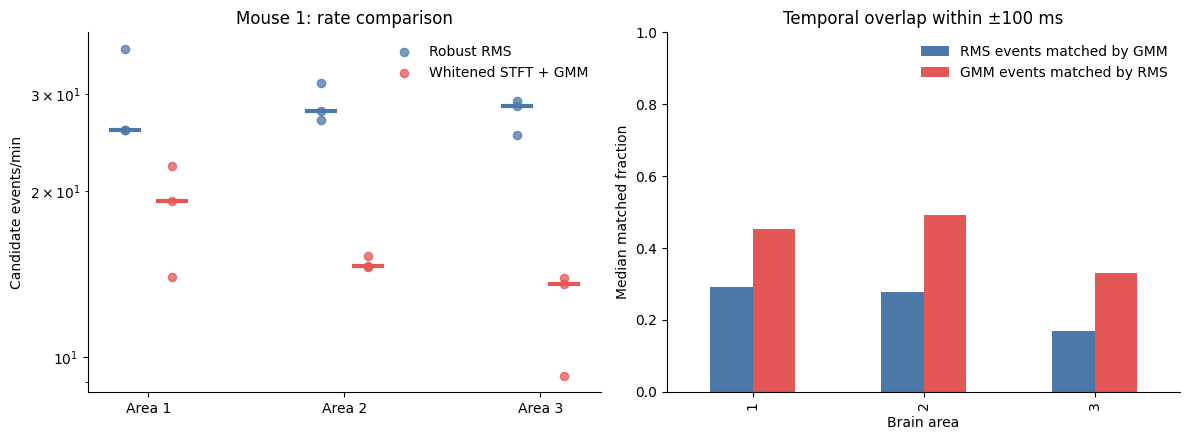

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
method_colors = {'Robust RMS': '#4C78A8', 'Whitened STFT + GMM': '#E45756'}
for method, method_frame in channel_results.groupby('method'):
    for area in (1, 2, 3):
        values = method_frame.loc[
            method_frame.brain_area == area, 'events_per_min'
        ].to_numpy()
        x_offset = -0.12 if method == 'Robust RMS' else 0.12
        axes[0].scatter(
            np.full(len(values), area + x_offset), values,
            color=method_colors[method], alpha=0.75, s=35,
            label=method if area == 1 else None,
        )
        axes[0].plot(
            [area - 0.07 + x_offset, area + 0.07 + x_offset],
            [np.median(values)] * 2,
            color=method_colors[method], linewidth=3,
        )
axes[0].set_xticks([1, 2, 3], ['Area 1', 'Area 2', 'Area 3'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Candidate events/min')
axes[0].set_title('Mouse 1: rate comparison')
axes[0].legend(frameon=False)

overlap_summary = overlap_results.groupby('brain_area')[
    ['RMS_matched_by_GMM', 'GMM_matched_by_RMS']
].median()
overlap_summary.plot.bar(ax=axes[1], color=['#4C78A8', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Brain area')
axes[1].set_ylabel('Median matched fraction')
axes[1].set_title('Temporal overlap within ±100 ms')
axes[1].legend(['RMS events matched by GMM', 'GMM events matched by RMS'], frameon=False)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## Decision after the Mouse 1 audit

The 64 ms / 1.5-MAD revision brought the GMM estimates into the same broad order of magnitude as RMS, but it did **not** validate the same event population:

- RMS ranks Area 3 > Area 2 > Area 1.
- GMM ranks Area 1 > Area 2 > Area 3.
- GMM/RMS median rate ratios are approximately 0.74, 0.52, and 0.47 for Areas 1–3.
- Only about 8–35% of RMS candidates match a GMM candidate within ±100 ms, depending on channel.

A bounded sensitivity grid varied the candidate gate (1.25, 1.5, 1.75, or 2 robust SD) and GMM complexity (2, 3, or 4 components). Across the 12 combinations, Area 1 won five times, Area 2 won seven times, and Area 3 never won. Thus, tuning can move the GMM rate into the RMS range but does not recover a stable conclusion or the RMS ranking.

Because the inferred winner and most individual events remain detector-dependent on Mouse 1, the GMM is **retired as a confirmatory pipeline** rather than tuned until it agrees. The all-mouse analysis will use the robust RMS detector. The GMM code remains here as a transparent negative result.